# Reducer Benchmark Graphs

In [10]:
# Setup
from pathlib import Path
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("benchmark_graphs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Mock input data for 20 queries. Replace these lists with real benchmark data.
query_ids = list(range(1, 21))
labels = [f"Q{query_id}" for query_id in query_ids]

#TODO: This is just mock data, we need to replace it with our actual data to generate figures for the report.
original_tokens = [
    216,
    481,
    1564,
    955,
    68,
    3810,
    619,
    1694,
    1245,
    259,
    114,
    3818,
    287,
    10787,
    224,
    5051,
    10559,
    209,
    211,
    9539
]
final_tokens = [
    50,
    481,
    1564,
    124,
    40,
    112,
    619,
    190,
    1245,
    259,
    49,
    3818,
    49,
    10787,
    113,
    1844,
    10559,
    111,
    91,
    115
]
wall_clock_seconds = [
    5.1625081140000475,
    1.4021215909997409,
    3.6714137190001566,
    8.866048819999833,
    1.877210100999946,
    7.583683450999615,
    17.759168561000024,
    13.707535600000028,
    4.8598617560001,
    1.4057139780002217,
    3.7433337309998933,
    15.34381755000004,
    2.652985661999992,
    33.92185595000001,
    4.067835181999726,
    1920.7173077909997,
    10.04329267400044,
    3.568593842000155,
    7.6928609209999195,
    4.198983319000035
]

def percentage_reductions(original: list[float], final: list[float]) -> list[float]:
    reductions: list[float] = []
    for original_count, final_count in zip(original, final, strict=True):
        if original_count <= 0:
            reductions.append(0.0)
        else:
            reductions.append(max(0.0, (original_count - final_count) / original_count * 100.0))
    return reductions

def reductions_per_second(reductions: list[float], seconds: list[float]) -> list[float]:
    rates: list[float] = []
    for reduction, duration in zip(reductions, seconds, strict=True):
        if duration <= 0:
            rates.append(0.0)
        else:
            rates.append(reduction / duration)
    return rates

def draw_bar_chart(title: str, y_label: str, values: list[float], color: str, output_name: str):
    fig, ax = plt.subplots(figsize=(12, 4.8), constrained_layout=True)
    bars = ax.bar(labels, values, color=color)
    ax.set_title(title)
    ax.set_xlabel("Benchmark query")
    ax.set_ylabel(y_label)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.bar_label(bars, fmt="%.1f", fontsize=8, padding=2)
    ax.tick_params(axis="x", rotation=45)
    # TODO: Uncomment the line when we want to generate the final figures.
    # fig.savefig(OUTPUT_DIR / output_name, dpi=200)
    return fig, ax

token_reduction_percent = percentage_reductions(original_tokens, final_tokens)
token_reduction_percent_per_second = reductions_per_second(
    token_reduction_percent,
    wall_clock_seconds,
)

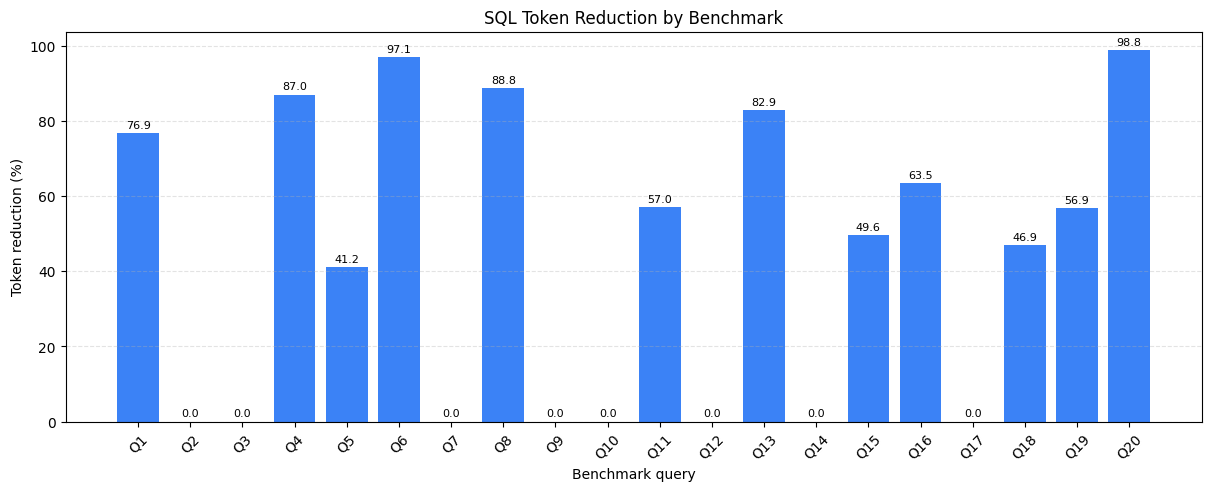

In [11]:
# Graph 1: percentage reduction in SQL tokens between original and final query
fig, ax = draw_bar_chart(
    title="SQL Token Reduction by Benchmark",
    y_label="Token reduction (%)",
    values=token_reduction_percent,
    color="#3b82f6",
    output_name="token_reduction_percent.png",
)

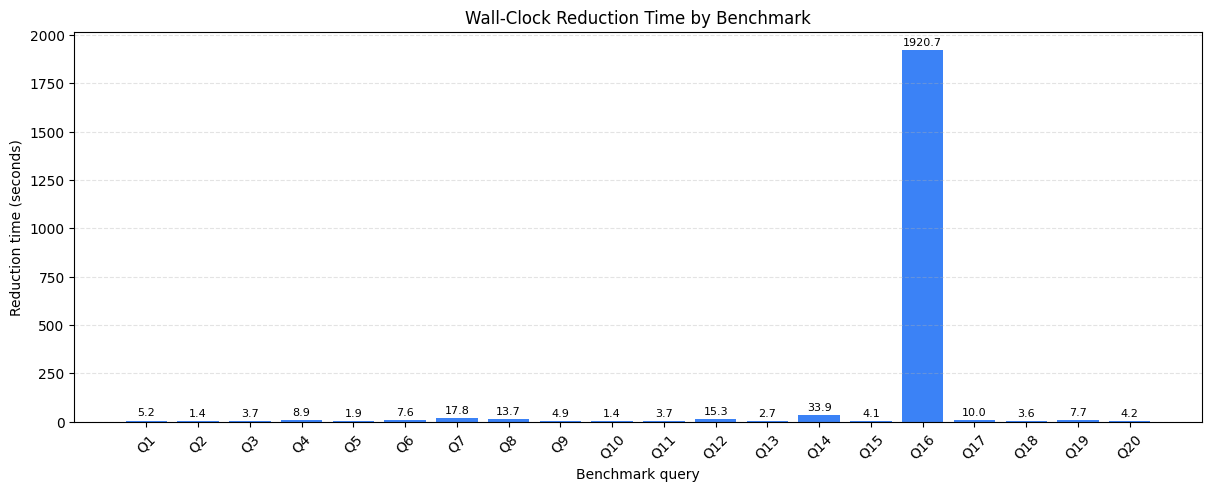

In [12]:
# Graph 2: wall-clock time required to reduce each benchmark
fig, ax = draw_bar_chart(
    title="Wall-Clock Reduction Time by Benchmark",
    y_label="Reduction time (seconds)",
    values=wall_clock_seconds,
    color="#3b82f6",
    output_name="wall_clock_seconds.png",
)

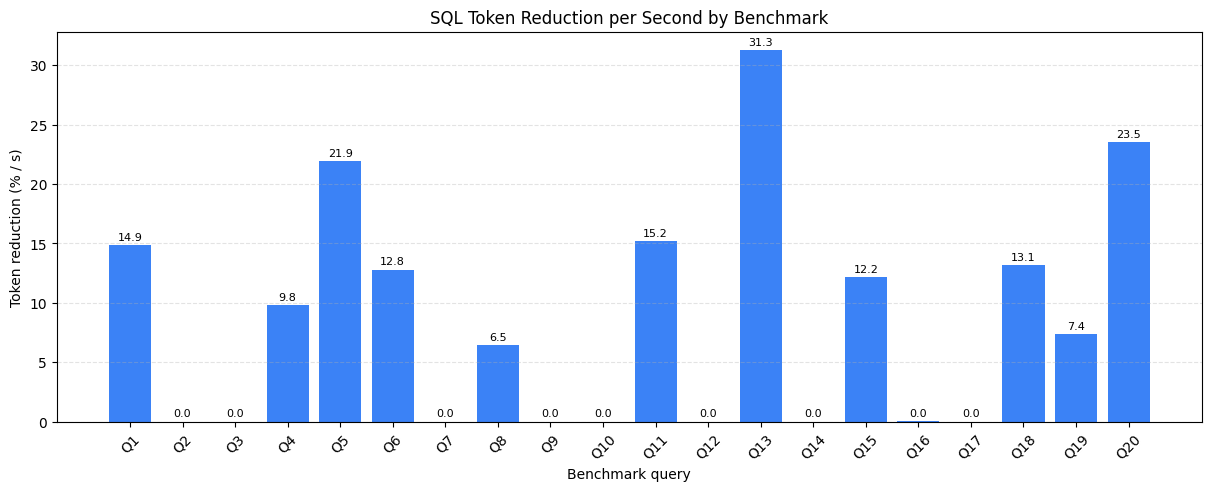

In [13]:
# Graph 3: percentage reduction in SQL tokens per second
fig, ax = draw_bar_chart(
    title="SQL Token Reduction per Second by Benchmark",
    y_label="Token reduction (% / s)",
    values=token_reduction_percent_per_second,
    color="#3b82f6",
    output_name="token_reduction_percent_per_second.png",
)